In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

2026-03-18 06:11:30.921810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773814291.121656      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773814291.175992      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773814291.632802      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773814291.632849      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773814291.632852      55 computation_placer.cc:177] computation placer alr

In [2]:
train_path = '/kaggle/input/datasets/abhinav6744/apple-disease-data/apple/datasets/train/'
test_path  = '/kaggle/input/datasets/abhinav6744/apple-disease-data/apple/datasets/test/'

print("Train classes:", os.listdir(train_path))
print("Test classes:", os.listdir(test_path))

Train classes: ['black_rot', 'healthy', 'cedar_apple_rust', 'apple_scab']
Test classes: ['black_rot', 'healthy', 'cedar_apple_rust', 'apple_scab']


In [3]:
for cls in os.listdir(train_path):
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  {cls} → {count} images")

  black_rot → 1987 images
  healthy → 2008 images
  cedar_apple_rust → 1760 images
  apple_scab → 2016 images


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

print("Classes:", train_generator.class_indices)
NUM_CLASSES = len(train_generator.class_indices)
print("Total classes:", NUM_CLASSES)

Found 7771 images belonging to 4 classes.
Found 1943 images belonging to 4 classes.
Classes: {'apple_scab': 0, 'black_rot': 1, 'cedar_apple_rust': 2, 'healthy': 3}
Total classes: 4


In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773814333.038220      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773814333.043851      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1773814376.751954     142 service.cc:152] XLA service 0x7e5f10004b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773814376.751993     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773814376.751998     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773814377.193095     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/243 ━━━━━━━━━━━━━━━━━━━━ 25:09 6s/step - accuracy: 0.2500 - loss: 1.3891

I0000 00:00:1773814381.213372     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


243/243 ━━━━━━━━━━━━━━━━━━━━ 84s 323ms/step - accuracy: 0.6093 - loss: 0.9521 - val_accuracy: 0.7735 - val_loss: 0.6755
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 51s 210ms/step - accuracy: 0.8661 - loss: 0.3672 - val_accuracy: 0.8641 - val_loss: 0.4016
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 52s 214ms/step - accuracy: 0.8906 - loss: 0.3026 - val_accuracy: 0.9099 - val_loss: 0.2586
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 52s 212ms/step - accuracy: 0.9208 - loss: 0.2310 - val_accuracy: 0.9264 - val_loss: 0.2194
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 51s 210ms/step - accuracy: 0.9465 - loss: 0.1590 - val_accuracy: 0.9182 - val_loss: 0.1984
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 51s 209ms/step - accuracy: 0.9463 - loss: 0.1534 - val_accuracy: 0.9336 - val_loss: 0.1669
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 51s 209ms/step - accuracy: 0.9590 - loss: 0.1226 - val_accuracy: 0.9454 - val_loss: 0.1626
Epoch 8/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 50s 206ms/step - accuracy: 0.9688 - loss: 0.0874 - val

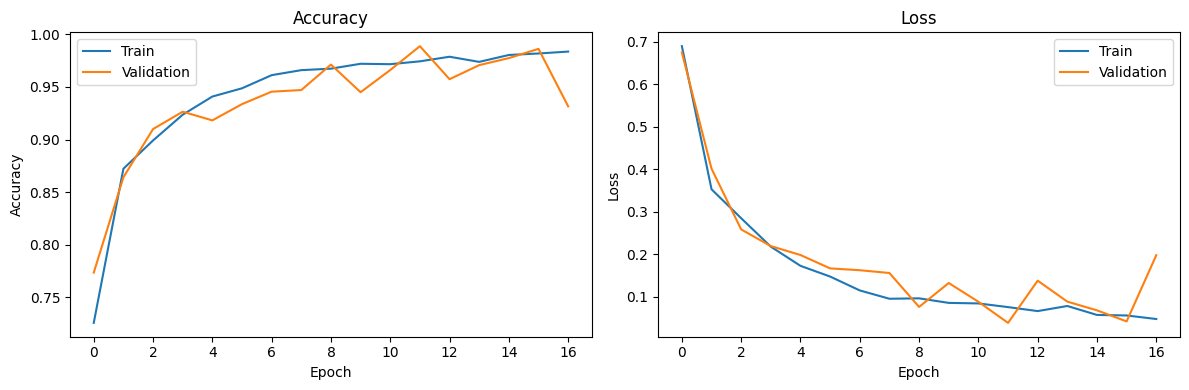

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9862 - loss: 0.0454
Final Validation Accuracy: 98.87%
Final Validation Loss: 0.0386


In [11]:
model.save('/kaggle/working/apple_model.h5')

labels = [label for label, index in sorted(train_generator.class_indices.items(), key=lambda x: x[1])]

with open('/kaggle/working/apple_labels.txt', 'w') as f:
    for label in labels:
        f.write(label + '\n')

print("Model saved!")
print("Labels saved:", labels)

Model saved!
Labels saved: ['apple_scab', 'black_rot', 'cedar_apple_rust', 'healthy']
